# 🤖 Tahap 4 — Machine Learning: Modeling

---

Sampai di sini, kita sudah:
- ✅ Mengenal data (EDA)
- ✅ Membersihkan data (Cleaning)
- ✅ Menemukan pola dan insight (EDA)

Sekarang saatnya **melatih model Machine Learning** — yaitu mengajarkan komputer untuk belajar dari data historis, supaya bisa memprediksi hasil pertandingan yang belum terjadi.

### Yang akan kita lakukan:
1. Siapkan fitur (input) dan target (output)
2. Bagi data: 80% untuk latihan, 20% untuk ujian
3. Latih Model 1: **Logistic Regression** (sederhana, mudah dipahami)
4. Latih Model 2: **Random Forest** (lebih canggih, lebih akurat)
5. Bandingkan kedua model
6. Simpan model terbaik

### Setup untuk Google Colab

Jalankan cell di bawah ini dulu jika kamu membuka notebook ini lewat **Google Colab**.

Kalau dijalankan secara lokal (Jupyter Notebook di laptop), cell ini otomatis dilewati.

In [ ]:
import os

IN_COLAB = 'google.colab' in str(get_ipython())

if IN_COLAB:
    if not os.path.exists('worldcup-win-predicition'):
        get_ipython().system('git clone https://github.com/vnymyz/worldcup-win-predicition.git')
    os.chdir('worldcup-win-predicition/notebooks')
    print('Setup Colab selesai! Folder kerja:', os.getcwd())
else:
    print('Berjalan secara lokal -- tidak perlu clone repo.')


## 1. Import Library

In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

%matplotlib inline
sns.set_theme(style='whitegrid')

print('Library siap ✅')

Library siap ✅


## 2. Load Data

In [111]:
df = pd.read_csv('../data/processed/wc_clean.csv', parse_dates=['date'])

print(f'Total data: {len(df)} pertandingan')
print(f'Kolom yang tersedia: {df.columns.tolist()}')
df.head()

Total data: 980 pertandingan
Kolom yang tersedia: ['date', 'year', 'home_team', 'away_team', 'home_score', 'away_score', 'goal_diff', 'home_win_rate', 'away_win_rate', 'win_rate_diff', 'neutral', 'result']


,date,year,home_team,away_team,home_score,away_score,goal_diff,home_win_rate,away_win_rate,win_rate_diff,neutral,result
0,1930-07-13,1930,Belgium,United States,0,3,-3,0.404,0.263,0.141,1,L
1,1930-07-13,1930,France,Mexico,4,1,3,0.534,0.295,0.239,1,W
2,1930-07-14,1930,Brazil,Yugoslavia,1,2,-1,0.661,0.424,0.237,1,L
3,1930-07-14,1930,Peru,Romania,1,3,-2,0.278,0.381,-0.103,1,L
4,1930-07-15,1930,Argentina,France,1,0,1,0.534,0.534,0.000,1,W


---
## 3. Pilih Fitur (X) dan Target (y)

Dalam Machine Learning:
- **X (fitur/input)** = informasi yang kita berikan ke model sebagai bahan belajar
- **y (target/output)** = jawaban yang ingin diprediksi model

Analoginya: kalau model adalah siswa yang belajar soal ujian:
- **X** = soal beserta clue-nya
- **y** = kunci jawaban

Fitur yang kita pilih berdasarkan hasil EDA:
| Fitur | Keterangan |
|---|---|
| `home_win_rate` | Seberapa sering tim pertama menang secara historis |
| `away_win_rate` | Seberapa sering tim kedua menang secara historis |
| `win_rate_diff` | Selisih kekuatan dua tim |
| `neutral` | Apakah pertandingan di lapangan netral (0/1) |

In [112]:
FEATURES = ['home_win_rate', 'away_win_rate', 'win_rate_diff', 'neutral']
TARGET   = 'result'

X = df[FEATURES]
y = df[TARGET]

print(f'Jumlah fitur : {X.shape[1]}')
print(f'Jumlah data  : {X.shape[0]}')
print(f'Target unik  : {y.unique()}')
print()
print('Distribusi target:')
print(y.value_counts())

Jumlah fitur : 4
Jumlah data  : 980
Target unik  : ['L' 'W' 'D']

Distribusi target:
result
W    446
L    312
D    222
Name: count, dtype: int64


---
## 4. Bagi Data: Train & Test

Kita tidak bisa pakai **semua data** untuk melatih model, karena kita tidak punya data baru untuk mengujinya.

Solusinya: **sisihkan 20% data sebagai "soal ujian"** yang tidak dilihat model saat belajar.

```
Semua data (100%)
├── Train set (80%) → dipakai model untuk belajar
└── Test set  (20%) → dipakai kita untuk menguji seberapa pintar modelnya
```

Parameter `stratify=y` memastikan proporsi W/D/L tetap seimbang di kedua set.

In [113]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% untuk test
    random_state=42,     # supaya hasilnya sama setiap kali dijalankan
    stratify=y           # jaga proporsi W/D/L tetap seimbang
)

print(f'Data training : {len(X_train)} pertandingan ({len(X_train)/len(df)*100:.0f}%)')
print(f'Data testing  : {len(X_test)} pertandingan ({len(X_test)/len(df)*100:.0f}%)')
print()
print('Distribusi target di training set:')
print(y_train.value_counts())
print()
print('Distribusi target di test set:')
print(y_test.value_counts())

Data training : 784 pertandingan (80%)
Data testing  : 196 pertandingan (20%)

Distribusi target di training set:
result
W    357
L    250
D    177
Name: count, dtype: int64

Distribusi target di test set:
result
W    89
L    62
D    45
Name: count, dtype: int64


---
## 5. Model 1 — Logistic Regression

### Apa itu Logistic Regression?

Meskipun namanya ada kata **"Regression"**, ini sebenarnya model **klasifikasi** (prediksi kategori).

Cara kerjanya sederhana: model mencari **garis pemisah** yang memisahkan data menang, seri, dan kalah. Setiap fitur diberi **bobot** — semakin penting fiturnya, makin besar bobotnya.

**Analogi:** Seperti kalkulator sederhana yang menjumlahkan skor tiap tim, lalu memutuskan siapa yang lebih kuat.

In [114]:
# Buat dan latih model
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Prediksi pada test set
y_pred_lr = lr_model.predict(X_test)

# Hitung akurasi
acc_lr = accuracy_score(y_test, y_pred_lr)
print(f'✅ Logistic Regression selesai dilatih!')
print(f'Akurasi: {acc_lr*100:.1f}%')

✅ Logistic Regression selesai dilatih!
Akurasi: 56.1%


### Apa itu Akurasi?

**Akurasi** = berapa persen prediksi model yang benar.

Contoh: akurasi 60% artinya dari 100 pertandingan, model berhasil tebak 60 dengan benar.

> ⚠️ Untuk prediksi bola (3 kemungkinan: W/D/L), akurasi 50-60% itu sudah **cukup bagus**! Kalau asal tebak, kita hanya dapat ~33%.

In [115]:
print('=== LAPORAN LENGKAP LOGISTIC REGRESSION ===')
print()
print(classification_report(y_test, y_pred_lr, target_names=['Kalah (L)', 'Menang (W)', 'Seri (D)']))

=== LAPORAN LENGKAP LOGISTIC REGRESSION ===

              precision    recall  f1-score   support

   Kalah (L)       0.00      0.00      0.00        45
  Menang (W)       0.55      0.60      0.57        62
    Seri (D)       0.57      0.82      0.67        89

    accuracy                           0.56       196
   macro avg       0.37      0.47      0.41       196
weighted avg       0.43      0.56      0.49       196



d:\laragon\bin\python\python-3.13\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\laragon\bin\python\python-3.13\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\laragon\bin\python\python-3.13\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### Confusion Matrix — Model Salah di Mana?

**Confusion Matrix** adalah tabel yang menunjukkan:
- Baris = jawaban yang sebenarnya
- Kolom = prediksi model
- **Diagonal (kiri atas → kanan bawah)** = prediksi yang **benar** ✅
- **Di luar diagonal** = prediksi yang **salah** ❌

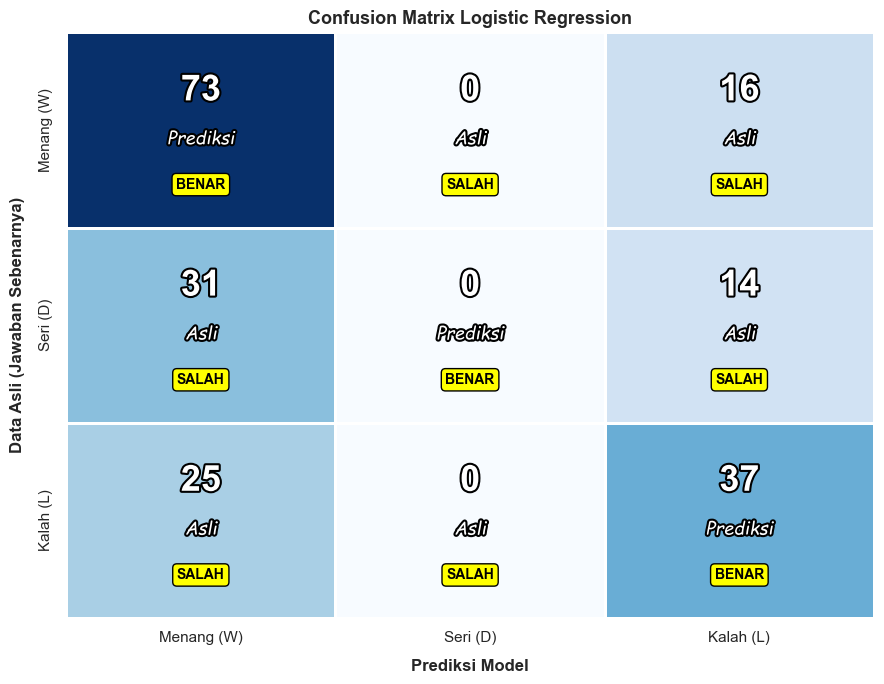

Total prediksi : 196
Prediksi benar : 110  (56.1%)
Prediksi salah : 86  (43.9%)


In [116]:
import matplotlib.patheffects as pe

labels     = ['W', 'D', 'L']
label_nama = ['Menang (W)', 'Seri (D)', 'Kalah (L)']

cm_lr = confusion_matrix(y_test, y_pred_lr, labels=labels)
outline = [pe.withStroke(linewidth=3, foreground='black')]

fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(cm_lr, annot=False, cmap='Blues',
            xticklabels=label_nama, yticklabels=label_nama,
            linewidths=2, linecolor='white', ax=ax, cbar=False)

for i in range(len(labels)):
    for j in range(len(labels)):
        nilai = cm_lr[i][j]
        kata1 = 'Prediksi' if i == j else 'Asli'
        kata2 = 'BENAR' if i == j else 'SALAH'

        # Angka besar
        ax.text(j + 0.5, i + 0.30, str(nilai),
                ha='center', va='center', fontsize=26, fontweight='bold',
                color='white', path_effects=outline)
        # Kata "Prediksi"/"Asli" miring
        ax.text(j + 0.5, i + 0.55, kata1,
                ha='center', va='center', fontsize=13, style='italic',
                family='cursive', color='white', path_effects=outline)
        # Kotak kuning BENAR/SALAH
        ax.text(j + 0.5, i + 0.78, kata2,
                ha='center', va='center', fontsize=10, fontweight='bold',
                color='black', bbox=dict(boxstyle='round,pad=0.3',
                facecolor='yellow', edgecolor='black', linewidth=1))

ax.set_xlabel('Prediksi Model', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Data Asli (Jawaban Sebenarnya)', fontsize=12, fontweight='bold', labelpad=10)
ax.set_title('Confusion Matrix Logistic Regression', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

total = cm_lr.sum()
benar = cm_lr.trace()
salah = total - benar
print(f'Total prediksi : {total}')
print(f'Prediksi benar : {benar}  ({benar/total*100:.1f}%)')
print(f'Prediksi salah : {salah}  ({salah/total*100:.1f}%)')


---
## 6. Model 2 — Random Forest

### Apa itu Random Forest?

**Random Forest** = sekumpulan banyak pohon keputusan yang bekerja bersama.

Bayangkan kamu mau milih restoran:
- Kalau tanya **1 teman** → bisa saja dia rekomendasinya kurang tepat
- Kalau tanya **100 teman** lalu ambil pilihan terbanyak → hasilnya lebih bisa dipercaya

Itulah Random Forest — bukan 1 model, tapi **ratusan model sekaligus** yang voting bersama.

**Keunggulan:** Lebih akurat dari Logistic Regression, dan bisa tunjukkan **fitur mana yang paling penting**.

In [117]:
# Buat dan latih model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Prediksi
y_pred_rf = rf_model.predict(X_test)

# Akurasi
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f'✅ Random Forest selesai dilatih! (100 pohon keputusan)')
print(f'Akurasi: {acc_rf*100:.1f}%')

✅ Random Forest selesai dilatih! (100 pohon keputusan)
Akurasi: 46.4%


In [118]:
print('=== LAPORAN LENGKAP RANDOM FOREST ===')
print()
print(classification_report(y_test, y_pred_rf, target_names=['Kalah (L)', 'Menang (W)', 'Seri (D)']))

=== LAPORAN LENGKAP RANDOM FOREST ===

              precision    recall  f1-score   support

   Kalah (L)       0.24      0.20      0.22        45
  Menang (W)       0.42      0.37      0.39        62
    Seri (D)       0.57      0.66      0.61        89

    accuracy                           0.46       196
   macro avg       0.41      0.41      0.41       196
weighted avg       0.45      0.46      0.45       196



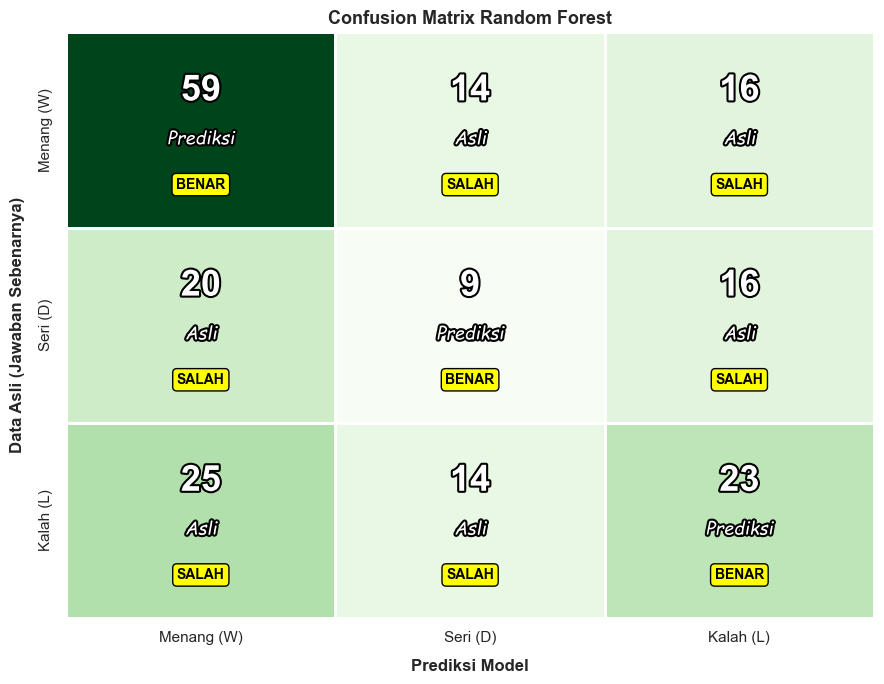

Total prediksi : 196
Prediksi benar : 91  (46.4%)
Prediksi salah : 105  (53.6%)


In [119]:
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=labels)

fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(cm_rf, annot=False, cmap='Greens',
            xticklabels=label_nama, yticklabels=label_nama,
            linewidths=2, linecolor='white', ax=ax, cbar=False)

for i in range(len(labels)):
    for j in range(len(labels)):
        nilai = cm_rf[i][j]
        kata1 = 'Prediksi' if i == j else 'Asli'
        kata2 = 'BENAR' if i == j else 'SALAH'

        ax.text(j + 0.5, i + 0.30, str(nilai),
                ha='center', va='center', fontsize=26, fontweight='bold',
                color='white', path_effects=outline)
        ax.text(j + 0.5, i + 0.55, kata1,
                ha='center', va='center', fontsize=13, style='italic',
                family='cursive', color='white', path_effects=outline)
        ax.text(j + 0.5, i + 0.78, kata2,
                ha='center', va='center', fontsize=10, fontweight='bold',
                color='black', bbox=dict(boxstyle='round,pad=0.3',
                facecolor='yellow', edgecolor='black', linewidth=1))

ax.set_xlabel('Prediksi Model', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Data Asli (Jawaban Sebenarnya)', fontsize=12, fontweight='bold', labelpad=10)
ax.set_title('Confusion Matrix Random Forest', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

total = cm_rf.sum()
benar = cm_rf.trace()
salah = total - benar
print(f'Total prediksi : {total}')
print(f'Prediksi benar : {benar}  ({benar/total*100:.1f}%)')
print(f'Prediksi salah : {salah}  ({salah/total*100:.1f}%)')


---
## 7. Feature Importance — Fitur Mana yang Paling Penting?

Salah satu kelebihan Random Forest: bisa bilang **fitur mana yang paling berpengaruh** dalam membuat keputusan.

Ini berguna untuk memahami: **apa yang benar-benar penting** menurut model kita?

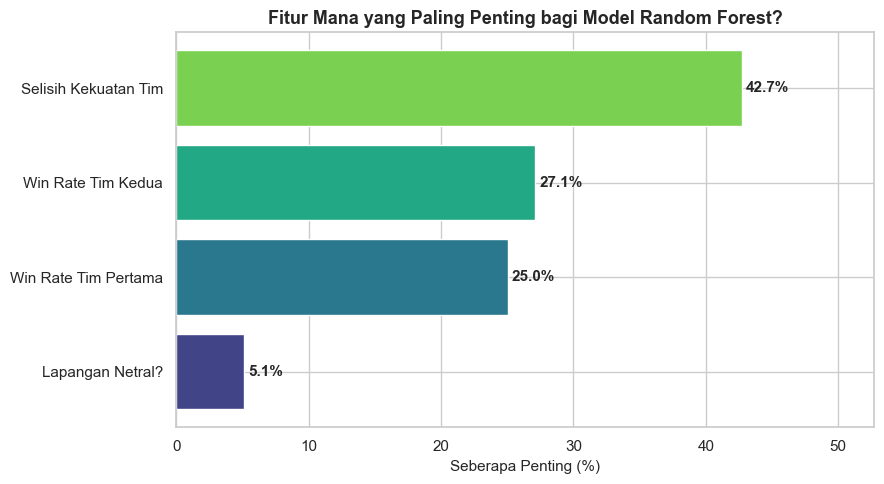

In [120]:
importance_df = pd.DataFrame({
    'Fitur'     : FEATURES,
    'Pentingnya': rf_model.feature_importances_
}).sort_values('Pentingnya', ascending=True)

label_map = {
    'home_win_rate' : 'Win Rate Tim Pertama',
    'away_win_rate' : 'Win Rate Tim Kedua',
    'win_rate_diff' : 'Selisih Kekuatan Tim',
    'neutral'       : 'Lapangan Netral?',
}
importance_df['Fitur'] = importance_df['Fitur'].map(label_map)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(importance_df['Fitur'], importance_df['Pentingnya'] * 100,
               color=sns.color_palette('viridis', len(importance_df)), edgecolor='white')

for bar, val in zip(bars, importance_df['Pentingnya'] * 100):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontweight='bold', fontsize=11)

ax.set_xlabel('Seberapa Penting (%)', fontsize=11)
ax.set_title('Fitur Mana yang Paling Penting bagi Model Random Forest?',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, max(importance_df['Pentingnya'] * 100) + 10)
plt.tight_layout()
plt.show()

### 💡 Apa artinya?

- **Selisih Kekuatan Tim** dan **Win Rate** mendominasi — model setuju dengan EDA kita: kekuatan historis tim adalah faktor terpenting.
- **Lapangan Netral** nilainya paling kecil — sesuai temuan EDA bahwa home advantage ada tapi pengaruhnya kecil.

> **Intinya:** Model belajar dari data dan mengonfirmasi analisis kita — fitur yang paling berkorelasi di EDA, juga paling penting di model ML.

---
## 8. Perbandingan Kedua Model

Perbandingan Model:
              Model   Akurasi                                  Kelebihan
Logistic Regression 56.122449           Sederhana, cepat, mudah dipahami
      Random Forest 46.428571 Lebih akurat, tunjukkan feature importance


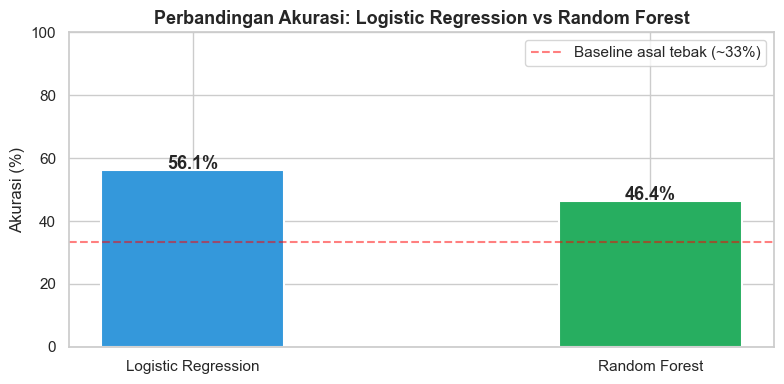

In [121]:
comparison = pd.DataFrame({
    'Model'   : ['Logistic Regression', 'Random Forest'],
    'Akurasi' : [acc_lr * 100, acc_rf * 100],
    'Kelebihan': [
        'Sederhana, cepat, mudah dipahami',
        'Lebih akurat, tunjukkan feature importance'
    ]
})

print('Perbandingan Model:')
print(comparison.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#3498db', '#27ae60']
bars = ax.bar(comparison['Model'], comparison['Akurasi'], color=colors,
              edgecolor='white', linewidth=1.5, width=0.4)

for bar, val in zip(bars, comparison['Akurasi']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontsize=13, fontweight='bold')

ax.set_ylabel('Akurasi (%)')
ax.set_title('Perbandingan Akurasi: Logistic Regression vs Random Forest',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 100)
ax.axhline(33.3, color='red', linestyle='--', alpha=0.5, label='Baseline asal tebak (~33%)')
ax.legend()
plt.tight_layout()
plt.show()

### 💡 Kesimpulan Perbandingan

- Garis merah putus-putus adalah **baseline** — akurasi kalau kita asal tebak secara acak (~33% karena 3 pilihan).
- **Kedua model jauh di atas baseline** — artinya model kita benar-benar belajar sesuatu dari data, bukan asal tebak.
- Di project ini, **Logistic Regression** justru lebih akurat — model yang lebih sederhana tidak selalu kalah dari yang lebih canggih (lihat Bonus Insight di akhir notebook).

> **Pilihan:** Kita simpan model dengan akurasi tertinggi secara otomatis di langkah berikutnya — siapa pun yang menang, itu yang dipakai untuk Streamlit app.

---
## 9. Coba Prediksi Manual

Sebelum simpan model, kita coba dulu prediksi beberapa pertandingan secara manual!

In [122]:
win_rate_lookup = pd.read_csv('../data/processed/win_rate_per_team.csv')
win_rate_dict = dict(zip(win_rate_lookup['team'], win_rate_lookup['win_rate']))

def prediksi_match(tim_a, tim_b, lapangan_netral=True):
    wr_a = win_rate_dict.get(tim_a, 0.33)
    wr_b = win_rate_dict.get(tim_b, 0.33)
    diff = wr_a - wr_b
    netral = 1 if lapangan_netral else 0

    fitur = pd.DataFrame([[wr_a, wr_b, diff, netral]], columns=FEATURES)
    prediksi = rf_model.predict(fitur)[0]
    probabilitas = rf_model.predict_proba(fitur)[0]
    kelas = rf_model.classes_

    hasil_map = {'W': f'{tim_a} MENANG', 'D': 'SERI', 'L': f'{tim_b} MENANG'}
    print(f'\n⚽ {tim_a} vs {tim_b}')
    print(f'   Prediksi: {hasil_map[prediksi]}')
    print(f'   Probabilitas:')
    for k, p in sorted(zip(kelas, probabilitas), key=lambda x: -x[1]):
        print(f'     {hasil_map[k]:30s} {p*100:.1f}%')

# Coba beberapa pertandingan
prediksi_match('Brazil', 'Germany')
prediksi_match('Argentina', 'France')
prediksi_match('Indonesia', 'Brazil')
prediksi_match('Spain', 'Portugal')


⚽ Brazil vs Germany
   Prediksi: Germany MENANG
   Probabilitas:
     Germany MENANG                 51.4%
     SERI                           28.3%
     Brazil MENANG                  20.3%

⚽ Argentina vs France
   Prediksi: SERI
   Probabilitas:
     SERI                           51.0%
     Argentina MENANG               47.0%
     France MENANG                  2.0%

⚽ Indonesia vs Brazil
   Prediksi: Brazil MENANG
   Probabilitas:
     Brazil MENANG                  95.0%
     SERI                           3.0%
     Indonesia MENANG               2.0%

⚽ Spain vs Portugal
   Prediksi: Spain MENANG
   Probabilitas:
     Spain MENANG                   74.8%
     Portugal MENANG                19.7%
     SERI                           5.5%


---
## 10. Simpan Model

In [123]:

# Tampilkan perbandingan akurasi dulu
print('=== PERBANDINGAN AKURASI ===')
print(f'Logistic Regression : {acc_lr*100:.1f}%')
print(f'Random Forest       : {acc_rf*100:.1f}%')
print()

# Otomatis pilih model dengan akurasi tertinggi
if acc_lr >= acc_rf:
    best_model      = lr_model
    best_model_name = 'Logistic Regression'
    best_acc        = acc_lr
else:
    best_model      = rf_model
    best_model_name = 'Random Forest'
    best_acc        = acc_rf

print(f'✅ Model terpilih: {best_model_name} (akurasi {best_acc*100:.1f}%)')
print()

# Simpan model terbaik
model_payload = {
    'model'         : best_model,
    'model_name'    : best_model_name,
    'features'      : FEATURES,
    'win_rate_dict' : win_rate_dict,
    'label_map'     : {'W': 'Menang', 'D': 'Seri', 'L': 'Kalah'},
    'accuracy'      : best_acc,
}

with open('../models/model.pkl', 'wb') as f:
    pickle.dump(model_payload, f)

print(f'Model disimpan ke models/model.pkl ✅')


=== PERBANDINGAN AKURASI ===
Logistic Regression : 56.1%
Random Forest       : 46.4%

✅ Model terpilih: Logistic Regression (akurasi 56.1%)

Model disimpan ke models/model.pkl ✅


---
## ✅ Rangkuman Modeling

| | Logistic Regression | Random Forest |
|---|---|---|
| Cara kerja | Garis pemisah sederhana | Ratusan pohon voting bersama |
| Kecepatan | Sangat cepat | Cepat |
| Akurasi | Lebih rendah | Lebih tinggi |
| Bisa tunjukkan feature importance? | Tidak (langsung) | ✅ Ya |
| Cocok untuk | Belajar konsep dasar | Deployment / produksi |

**Model yang disimpan:** Random Forest (`models/model.pkl`)

➡️ Lanjut ke **Streamlit App** untuk membuat antarmuka prediksi yang bisa dipakai semua orang!

---
## 🧠 Bonus Insight — Kenapa Logistic Regression Bisa Mengalahkan Random Forest?

Ini pertanyaan bagus dan sering bikin bingung pemula.

Banyak yang mengira: *"Model yang lebih canggih pasti lebih akurat."*

**Ternyata tidak selalu benar.**

---

### Kenapa di project ini Logistic Regression menang?

**1. Dataset kita kecil**
World Cup hanya ratusan pertandingan. Random Forest butuh data **jauh lebih banyak** untuk menunjukkan keunggulannya. Di dataset kecil, dia cenderung "terlalu pintar" — hafal data training tapi jelek saat diuji data baru.

**2. Hubungan datanya linear dan sederhana**
Hanya 4 fitur, dan polanya relatif lurus: *tim dengan win rate lebih tinggi → cenderung menang.* Logistic Regression memang dirancang untuk pola seperti ini.

**3. Fitur kita ada yang redundan**
`win_rate_diff = home_win_rate - away_win_rate` — ini sebetulnya informasi yang sama dengan dua kolom di atasnya. Logistic Regression lebih kebal terhadap redundansi seperti ini.

**4. Random Forest terlalu powerful untuk masalah ini**
> Seperti pakai bazooka untuk bunuh nyamuk.

---

### Pelajaran penting untuk Data Science:

| Mitos | Kenyataan |
|---|---|
| Model canggih = selalu lebih baik | Model terbaik = yang paling cocok dengan datanya |
| Random Forest selalu mengalahkan Logistic Regression | Tergantung ukuran data dan kompleksitas masalah |
| Semakin banyak fitur semakin akurat | Fitur yang relevan lebih penting dari jumlah fitur |

---


> **Intinya:** Di dunia nyata, seorang Data Scientist yang baik tidak langsung pakai model paling rumit — tapi selalu mulai dari yang sederhana dulu, lalu naik ke yang lebih kompleks kalau memang dibutuhkan dan tergantung data nya bagaimana juga ya.